In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Load credentials from .env instead of hardcoding them 
load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

# SQLAlchemy's "engine" is the reusable connection object pandas uses under the hood
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [38]:
# Quick connection test 
test = pd.read_sql("SELECT COUNT(*) AS total_orders FROM order_features;", engine)
print(test)

   total_orders
0         99441


In [39]:
# Pull the core feature view into a DataFrame (view from sql)
# loading the SQL work into pandas
# so we can do distribution analysis
orders = pd.read_sql("SELECT * FROM order_features;", engine)
orders.shape

(99441, 15)

In [40]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value,freight_value,item_count,review_score,delivery_days,handling_days,transit_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,58.90,13.29,1.0,5.0,7.0,6.0,1.0,False
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,239.90,19.93,1.0,4.0,16.0,8.0,8.0,False
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,199.00,17.87,1.0,5.0,7.0,1.0,6.0,False
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,12.99,12.79,1.0,4.0,6.0,2.0,4.0,False
4,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:34,2017-05-17 11:05:55,2017-05-22 13:44:35,2017-06-06,21.90,12.69,1.0,4.0,6.0,1.0,5.0,False


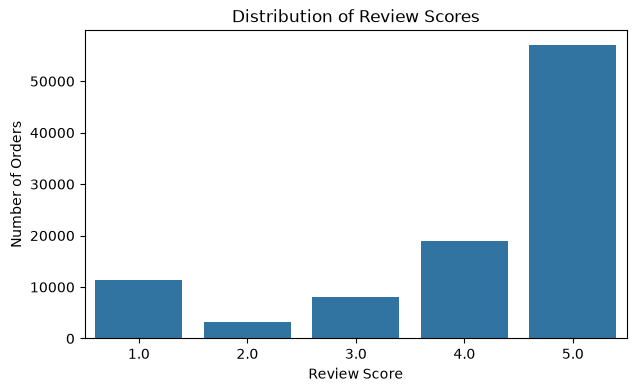

review_score
1.0    11.515815
2.0     3.173107
3.0     8.242376
4.0    19.294032
5.0    57.774670
Name: proportion, dtype: float64

In [ ]:
# PHASE 3: EXPLORATORY DATA ANALYSIS
plt.figure(figsize=(7, 4))
sns.countplot(data=orders, x="review_score", order=[1.0, 2.0, 3.0, 4.0, 5.0])
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.show()

orders["review_score"].value_counts(normalize=True).sort_index() * 100

Company is happy, but ideally we want all 5 stars

In [43]:
# ============================================
# 2. Missingness diagnostics
# ============================================
# What % of each column is missing? whether nulls are rare edge cases
# or a structural pattern we need to explicitly account for.
missing_pct = orders.isnull().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

transit_days                     2.982673
order_delivered_customer_date    2.981668
delivery_days                    2.981668
is_late                          2.981668
order_delivered_carrier_date     1.793023
handling_days                    1.793023
order_value                      0.779357
freight_value                    0.779357
item_count                       0.779357
review_score                     0.772317
dtype: float64

In [44]:
# Is review_score missing at random, or does it correlate with something?
# Compare delivery_days for orders WITH a review vs WITHOUT one.
orders.groupby(orders["review_score"].isnull())["delivery_days"].mean()

review_score
False    12.052760
True     18.224458
Name: delivery_days, dtype: float64

Missingness is not random. 
delivery = 18.22 days average missing a review
delivery = 12.05 days average if it has a review

** We used review_score IS NOT NULL
I systematically underrepresented slow delivery orders in all of it. 
LIMITATION: MNAR (Missing not at random) -> reason something is missing is tied to the very thing we try to measure.

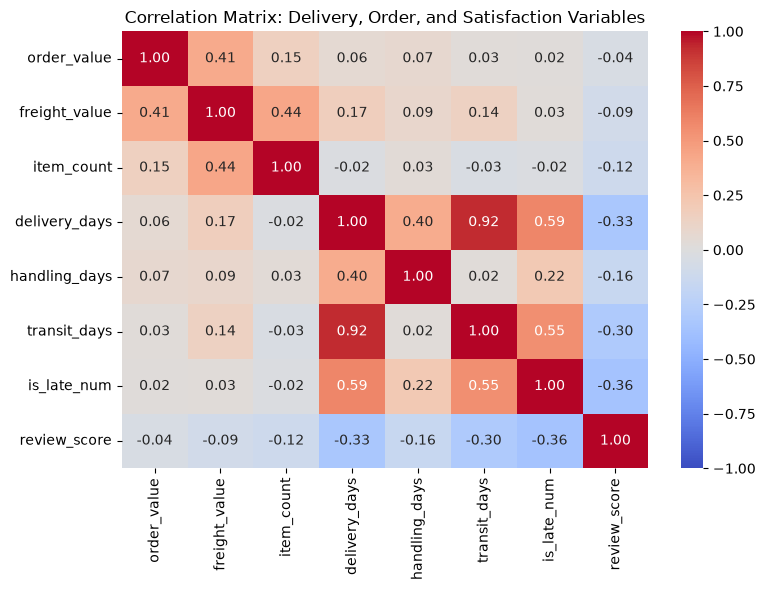

delivery_days vs is_late correlation: 0.5899326889824283
is_late_num     -0.364923
delivery_days   -0.333933
transit_days    -0.298729
handling_days   -0.156002
item_count      -0.115249
freight_value   -0.088320
order_value     -0.039360
review_score     1.000000
Name: review_score, dtype: float64


In [45]:
# ============================================
# 3. Correlation matrix of confounders
# ============================================
# is_late is boolean — convert to 0/1 so it can sit in a numeric correlation matrix
orders["is_late_num"] = orders["is_late"].astype(float)
 
confounder_cols = [
    "order_value", "freight_value", "item_count",
    "delivery_days", "handling_days", "transit_days",
    "is_late_num", "review_score"
]
 
corr_matrix = orders[confounder_cols].corr()
 
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix: Delivery, Order, and Satisfaction Variables")
plt.tight_layout()
plt.show()
 

# how correlated are
# delivery_days and is_late? If this is high (>0.7 is a common rule of thumb concern),
# it confirms we can't cleanly put both in a regression as independent predictors.
print("delivery_days vs is_late correlation:", corr_matrix.loc["delivery_days", "is_late_num"])
 
# Also worth checking: does review_score correlate more strongly with delivery_days
# or with is_late? 
print(corr_matrix["review_score"].sort_values())

Moderate multicollinearity needs further testing.

is_late_num correlates with review much stronger than delivery_days.
a customer who was told you get order in 20 days and gets in 18 is objectively happier than someone who was told order in 10 days and gets in 12. Even though faster, still unhappier. 
Expectation Management Finding

order_value doesnt correlate with review score at all, expensive orders arent less satisfying.